# Zero-Shot Classification with [BART](https://huggingface.co/facebook/bart-large-mnli)
Objective: Since South Park is well-known and may likely be in the training data for many LLMs, can a zero-shot classifier correctly identify the labels

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import sys
sys.path.append('../utils')

from evaluate_models import plot_confusion_matrix, print_evaluation_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

from transformers import pipeline # Use the setup on the documentation which directly uses the zero-shot-classification pipeline
import datasets # uv pip install datasets

Using device: cuda


c:\repos\Project_SP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load in only the test set. There is no training set since this is zero-shot classification
test_df = pd.read_parquet('../01 - Inputs/test_data.parquet')

In [3]:
candidate_labels = test_df['Character'].unique().tolist() # Get the unique character labels from the test set

In [4]:
# Define the model
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 989.99it/s, Materializing param=model.shared.weight]                                   


Interesting example. Since it doesn't know this is dialogue with speakers as labels, it sees that someone asks a question to Chef, sees the label for Chef, and thinks that it must match which is obviously incorrect

In [5]:
classifier("What are we doing here Chef?", candidate_labels)['labels'][0]

'Chef'

In [6]:
predictions = []
for line in tqdm(test_df['Line'].tolist()):
    output = classifier(line, candidate_labels)
    predictions.append(output['labels'][0])

100%|██████████| 6036/6036 [1:21:53<00:00,  1.23it/s]   


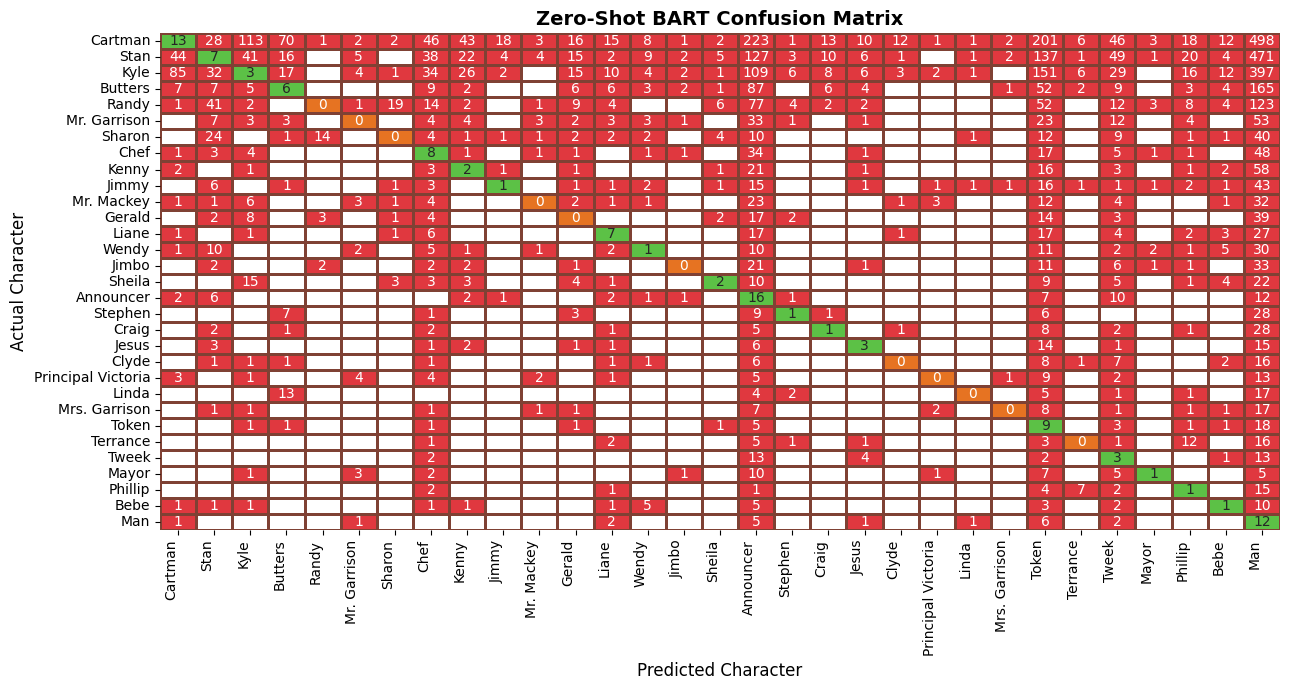

In [7]:
test_df['predicted_zero_shot'] = predictions

plot_confusion_matrix(
    y_true=test_df["Character"],
    y_pred=test_df["predicted_zero_shot"],
    title="Zero-Shot BART Confusion Matrix",
    save_path="../05 - Outputs/zero_shot_bart_confusion_matrix.png",
    figsize=(13, 7),
)

In [9]:
metrics_zero_shot = {
        'accuracy': accuracy_score(test_df['Character'], test_df['predicted_zero_shot']),
        'precision': precision_score(test_df['Character'], test_df['predicted_zero_shot'], average='macro', zero_division=0),
        'recall': recall_score(test_df['Character'], test_df['predicted_zero_shot'], average='macro', zero_division=0),
        'f1_score': f1_score(test_df['Character'], test_df['predicted_zero_shot'], average='macro', zero_division=0)
    }
pd.DataFrame([metrics_zero_shot], index = ["Zero-Shot BART"]).to_csv("../05 - Outputs/zero_shot_bart_metrics.csv")
print_evaluation_report(metrics_zero_shot, "Zero-Shot BART")


Zero-Shot BART Evaluation Results
Accuracy:  0.0162
Precision: 0.0247 (macro)
Recall:    0.0443 (macro)
F1-Score:  0.0180 (macro)

